In [1]:
# Cell 1 - Mount Drive and Load Data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import math
import heapq

adv_train = pd.read_parquet('/content/drive/MyDrive/SP2026_CMPE256_Group12_Data/advanced_train_temporal.parquet')
adv_test = pd.read_parquet('/content/drive/MyDrive/SP2026_CMPE256_Group12_Data/advanced_test_temporal.parquet')

print(f"Train: {adv_train.shape}")
print(f"Test: {adv_test.shape}")
print(adv_train.columns.tolist())

Mounted at /content/drive
Train: (3541459, 13)
Test: (885365, 13)
['user_id', 'item_id', 'rating', 'beer/name', 'beer/brewerId', 'beer/ABV', 'beer/style', 'review/appearance', 'review/aroma', 'review/palate', 'review/taste', 'review/time', 'review/text']


In [2]:
# Cell 2 - Build Beer Feature Matrix
from sklearn.feature_extraction.text import TfidfVectorizer

# Filter to popular items only (>=50 interactions)
item_counts = adv_train['item_id'].value_counts()
popular_items = item_counts[item_counts >= 50].index
filtered = adv_train[adv_train['item_id'].isin(popular_items)]
print(f"Popular items: {filtered['item_id'].nunique()}")
print(f"Filtered rows: {len(filtered)}")

# Build per-item average profiles
beer_profiles = filtered.groupby('item_id').agg({
    'beer/style': 'first',
    'beer/ABV': 'first',
    'review/appearance': 'mean',
    'review/aroma': 'mean',
    'review/palate': 'mean',
    'review/taste': 'mean',
    'rating': 'mean'
}).reset_index()

# Clean ABV
beer_profiles['beer/ABV'] = pd.to_numeric(beer_profiles['beer/ABV'], errors='coerce')
beer_profiles['beer/ABV'] = beer_profiles['beer/ABV'].fillna(beer_profiles['beer/ABV'].mean())

# TF-IDF on beer style
tfidf = TfidfVectorizer()
style_matrix = tfidf.fit_transform(beer_profiles['beer/style']).toarray()

# Normalize aspect ratings to 0-1
aspect_cols = ['beer/ABV', 'review/appearance', 'review/aroma',
               'review/palate', 'review/taste', 'rating']
aspect_matrix = beer_profiles[aspect_cols].values
aspect_matrix = (aspect_matrix - aspect_matrix.min(axis=0)) / (aspect_matrix.max(axis=0) - aspect_matrix.min(axis=0) + 1e-9)

# Combine style + aspects
item_feature_matrix = np.hstack([style_matrix, aspect_matrix])
item_ids = beer_profiles['item_id'].tolist()
item_idx = {item: i for i, item in enumerate(item_ids)}

print(f"Feature matrix shape: {item_feature_matrix.shape}")
print(f"Number of beers: {len(item_ids)}")

Popular items: 11676
Filtered rows: 2657680
Feature matrix shape: (11676, 165)
Number of beers: 11676


In [3]:
# Cell 3 - Train Autoencoder (best config: dim=64, 30 epochs)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X = torch.tensor(item_feature_matrix, dtype=torch.float32)
input_dim = item_feature_matrix.shape[1]

class BeerAutoencoder(nn.Module):
    def __init__(self, input_dim, embedding_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        embedding = self.encoder(x)
        reconstruction = self.decoder(embedding)
        return reconstruction, embedding

# Train
model_ae = BeerAutoencoder(input_dim=input_dim, embedding_dim=64)
optimizer = torch.optim.Adam(model_ae.parameters(), lr=0.001)
criterion = nn.MSELoss()

dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

print("Training autoencoder (dim=64, 30 epochs)...")
for epoch in range(30):
    total_loss = 0
    for batch in loader:
        x = batch[0]
        optimizer.zero_grad()
        recon, _ = model_ae(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/30, Loss: {total_loss/len(loader):.4f}")

print("Done!")

Training autoencoder (dim=64, 30 epochs)...
Epoch 5/30, Loss: 0.0043
Epoch 10/30, Loss: 0.0027
Epoch 15/30, Loss: 0.0021
Epoch 20/30, Loss: 0.0018
Epoch 25/30, Loss: 0.0016
Epoch 30/30, Loss: 0.0015
Done!


In [4]:
# Sanity check - Cell 4
model_ae.eval()
with torch.no_grad():
    _, embeddings = model_ae(X)
    embeddings = embeddings.numpy()

print(f"Embeddings shape: {embeddings.shape}")  # should be (11676, 64)
print(f"Train shape: {adv_train.shape}")  # (3541459, 13)
print(f"Test shape: {adv_test.shape}")  # (885365, 13)
print(f"Popular items: {len(item_ids)}")  # 11676
print(f"Feature matrix: {item_feature_matrix.shape}")  # (11676, 165)
print(f"Item idx size: {len(item_idx)}")  # 11676

# Check embedding range
print(f"\nEmbedding stats:")
print(f"  Min: {embeddings.min():.4f}")
print(f"  Max: {embeddings.max():.4f}")
print(f"  Mean: {embeddings.mean():.4f}")

# Check rating distribution
print(f"\nRating distribution in train:")
print(adv_train['rating'].describe())

Embeddings shape: (11676, 64)
Train shape: (3541459, 13)
Test shape: (885365, 13)
Popular items: 11676
Feature matrix: (11676, 165)
Item idx size: 11676

Embedding stats:
  Min: -3.3496
  Max: 2.2664
  Mean: 0.0616

Rating distribution in train:
count    3.541459e+06
mean     3.469910e+00
std      8.462733e-01
min      0.000000e+00
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [23]:
# Cell 5 - Grid Search for Best Embedding Dimension and Threshold
print("Running grid search for best embedding dimension and threshold...")
print(f"{'Emb Dim':<10} {'Threshold':<12} {'Precision':<12} {'Recall':<12} {'NDCG':<10}")
print("-" * 56)

best_ndcg = 0
best_config = {}
grid_results = []

for emb_dim in [16, 32, 64, 128]:
    model_gs = BeerAutoencoder(input_dim=input_dim, embedding_dim=emb_dim)
    optimizer_gs = torch.optim.Adam(model_gs.parameters(), lr=0.001)

    for epoch in range(30):
        for batch in loader:
            x = batch[0]
            optimizer_gs.zero_grad()
            recon, _ = model_gs(x)
            loss = criterion(recon, x)
            loss.backward()
            optimizer_gs.step()

    model_gs.eval()
    with torch.no_grad():
        _, emb_gs = model_gs(X)
        emb_gs = emb_gs.numpy()

    for threshold in [3.0, 3.5, 4.0]:
        results_gs = evaluate_cb_negative_sampling(
            filtered, adv_test, emb_gs, item_ids, item_idx,
            n=10, threshold=threshold, max_users=500,
            num_negatives=1000, random_state=42)

        p = results_gs['Precision@10']
        r = results_gs['Recall@10']
        n_score = results_gs['NDCG@10']

        grid_results.append({
            'emb_dim': emb_dim,
            'threshold': threshold,
            'precision': p,
            'recall': r,
            'ndcg': n_score
        })

        print(f"{emb_dim:<10} {threshold:<12} {p:<12.4f} {r:<12.4f} {n_score:<10.4f}")

        if n_score > best_ndcg:
            best_ndcg = n_score
            best_config = {'emb_dim': emb_dim, 'threshold': threshold}

print(f"\nBest config: embedding_dim={best_config['emb_dim']}, threshold={best_config['threshold']}")
print(f"Best NDCG@10: {best_ndcg:.4f}")

Running grid search for best embedding dimension and threshold...
Emb Dim    Threshold    Precision    Recall       NDCG      
--------------------------------------------------------
16         3.0          0.1122       0.0661       0.1330    
16         3.5          0.1123       0.0596       0.1320    
16         4.0          0.1069       0.0744       0.1309    
32         3.0          0.0815       0.0368       0.0869    
32         3.5          0.0654       0.0392       0.0721    
32         4.0          0.0570       0.0371       0.0626    
64         3.0          0.1020       0.0463       0.1135    
64         3.5          0.0951       0.0542       0.1102    
64         4.0          0.0832       0.0483       0.0993    
128        3.0          0.0468       0.0160       0.0488    
128        3.5          0.0506       0.0246       0.0559    
128        4.0          0.0354       0.0310       0.0415    

Best config: embedding_dim=16, threshold=3.0
Best NDCG@10: 0.1330


In [5]:
# Cell 5 - User Profile Function
def get_user_profile(user_id, train_df, embeddings, item_idx,
                     liked_threshold=3.5, disliked_threshold=2.5):
    user_ratings = train_df[train_df['user_id'] == user_id]
    user_ratings = user_ratings[user_ratings['item_id'].isin(item_idx)]

    if len(user_ratings) == 0:
        return None

    indices = [item_idx[i] for i in user_ratings['item_id']]
    ratings = user_ratings['rating'].values

    liked_mask = ratings >= liked_threshold
    disliked_mask = ratings <= disliked_threshold
    neutral_mask = ~liked_mask & ~disliked_mask

    if liked_mask.sum() == 0:
        return None

    # Positive signal — weighted by rating
    liked_profile = np.average(embeddings[indices][liked_mask],
                               axis=0, weights=ratings[liked_mask])

    # Negative signal — push away from disliked
    if disliked_mask.sum() > 0:
        disliked_profile = embeddings[indices][disliked_mask].mean(axis=0)
        liked_profile = liked_profile - 0.3 * disliked_profile

    # Neutral signal — low weight
    if neutral_mask.sum() > 0:
        neutral_profile = np.average(embeddings[indices][neutral_mask],
                                     axis=0, weights=ratings[neutral_mask] * 0.2)
        liked_profile = liked_profile + 0.1 * neutral_profile

    return liked_profile

print("✅ get_user_profile defined!")

✅ get_user_profile defined!


In [6]:
# Cell 6 - Negative Sampling Evaluation
def evaluate_cb_negative_sampling(train_df, test_df, embeddings, item_ids, item_idx,
                                   n=10, threshold=4.0, max_users=1000,
                                   num_negatives=1000, random_state=42):

    rng = np.random.default_rng(random_state)
    train_items = set(item_ids)

    # Get relevant test interactions
    positive_test = test_df[
        (test_df['item_id'].isin(train_items)) &
        (test_df['rating'] >= threshold)
    ].copy()

    relevant_items_per_user = (
        positive_test.groupby('user_id')['item_id'].apply(set).to_dict()
    )

    # Get train user history
    user_history = train_df.groupby('user_id')['item_id'].apply(set).to_dict()
    train_users = set(train_df['user_id'].unique())

    # Filter to users in both train and test
    eval_users = [u for u in relevant_items_per_user.keys() if u in train_users]
    if max_users and len(eval_users) > max_users:
        eval_users = rng.choice(eval_users, size=max_users, replace=False).tolist()

    precisions, recalls, ndcgs = [], [], []

    for user in eval_users:
        user_profile = get_user_profile(user, train_df, embeddings, item_idx,
                                        liked_threshold=3.5, disliked_threshold=2.5)
        if user_profile is None:
            continue

        seen_items = user_history.get(user, set())
        relevant_items = relevant_items_per_user[user] - seen_items
        if not relevant_items:
            continue

        # Sample negatives
        negative_pool = list(train_items - seen_items - relevant_items)
        if len(negative_pool) == 0:
            continue

        sampled_size = min(num_negatives, len(negative_pool))
        sampled_negatives = rng.choice(negative_pool, size=sampled_size,
                                        replace=False).tolist()

        # Score candidates (relevant + negatives)
        candidate_items = list(relevant_items) + sampled_negatives
        candidate_indices = [item_idx[item] for item in candidate_items
                            if item in item_idx]
        candidate_items_filtered = [item for item in candidate_items
                                   if item in item_idx]

        if len(candidate_indices) == 0:
            continue

        # Score using embeddings
        candidate_embeddings = embeddings[candidate_indices]
        scores = candidate_embeddings @ user_profile

        # Get top N
        top_n_idx = np.argsort(scores)[::-1][:n]
        top_n_items = [candidate_items_filtered[i] for i in top_n_idx]

        hits = [1 if item in relevant_items else 0 for item in top_n_items]

        k = min(n, len(top_n_items))
        precisions.append(sum(hits[:k]) / k)
        recalls.append(sum(hits[:k]) / len(relevant_items))
        dcg = sum(hit / math.log2(i + 2) for i, hit in enumerate(hits[:k]))
        ideal = sum(1 / math.log2(i + 2) for i in range(min(len(relevant_items), k)))
        ndcgs.append(dcg / ideal if ideal > 0 else 0)

    return {
        f'Precision@{n}': np.mean(precisions) if precisions else 0,
        f'Recall@{n}': np.mean(recalls) if recalls else 0,
        f'NDCG@{n}': np.mean(ndcgs) if ndcgs else 0,
        'num_eval_users': len(precisions)
    }

print("✅ evaluate_cb_negative_sampling defined!")

✅ evaluate_cb_negative_sampling defined!


In [7]:
# Cell 7 - Evaluate Content-Based Autoencoder (All Users, No Threshold)
print("Evaluating Content-Based Autoencoder (Negative Sampling)...")
print("(All users, no rating threshold)\n")

results = evaluate_cb_negative_sampling(
    train_df=filtered,
    test_df=adv_test,
    embeddings=embeddings,
    item_ids=item_ids,
    item_idx=item_idx,
    n=10,
    threshold=0.0,
    max_users=1000,
    num_negatives=1000,
    random_state=42
)

print("=== Content-Based Autoencoder Results (No Threshold) ===")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

Evaluating Content-Based Autoencoder (Negative Sampling)...
(All users, no rating threshold)

=== Content-Based Autoencoder Results (No Threshold) ===
Precision@10: 0.1117
Recall@10: 0.0560
NDCG@10: 0.1296
num_eval_users: 987


In [8]:
# Cell 8 - Cold Start vs Warm Users
train_user_counts = filtered['user_id'].value_counts()
warm_users = set(train_user_counts[train_user_counts >= 5].index)
cold_users = set(adv_test['user_id'].unique()) - warm_users

adv_test_warm = adv_test[adv_test['user_id'].isin(warm_users)]
adv_test_cold = adv_test[adv_test['user_id'].isin(cold_users)]

print(f"Warm users in test: {adv_test_warm['user_id'].nunique()}")
print(f"Cold users in test: {adv_test_cold['user_id'].nunique()}")

print("\n--- Warm Users ---")
warm_results = evaluate_cb_negative_sampling(
    filtered, adv_test_warm, embeddings, item_ids, item_idx,
    max_users=1000, num_negatives=1000)
for metric, value in warm_results.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

print("\n--- Cold Users ---")
cold_results = evaluate_cb_negative_sampling(
    filtered, adv_test_cold, embeddings, item_ids, item_idx,
    max_users=1000, num_negatives=1000)
for metric, value in cold_results.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

Warm users in test: 7116
Cold users in test: 13613

--- Warm Users ---
Precision@10: 0.0997
Recall@10: 0.0552
NDCG@10: 0.1161
num_eval_users: 999

--- Cold Users ---
Precision@10: 0.0537
Recall@10: 0.0958
NDCG@10: 0.0917
num_eval_users: 927


In [24]:
# Retrain with best config: dim=16, threshold=3.0
print("Retraining with best config: dim=16, threshold=3.0...")

model_best = BeerAutoencoder(input_dim=input_dim, embedding_dim=16)
optimizer_best = torch.optim.Adam(model_best.parameters(), lr=0.001)

for epoch in range(30):
    total_loss = 0
    for batch in loader:
        x = batch[0]
        optimizer_best.zero_grad()
        recon, _ = model_best(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer_best.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/30, Loss: {total_loss/len(loader):.4f}")

model_best.eval()
with torch.no_grad():
    _, embeddings_best = model_best(X)
    embeddings_best = embeddings_best.numpy()

print(f"Done! Embeddings shape: {embeddings_best.shape}")

Retraining with best config: dim=16, threshold=3.0...
Epoch 5/30, Loss: 0.0047
Epoch 10/30, Loss: 0.0030
Epoch 15/30, Loss: 0.0025
Epoch 20/30, Loss: 0.0021
Epoch 25/30, Loss: 0.0019
Epoch 30/30, Loss: 0.0018
Done! Embeddings shape: (11676, 16)


In [9]:
# Cell 9 - Final Evaluation on ALL Users (No Threshold)
print("Running FINAL evaluation on ALL users...")

# All users
print("--- All Users ---")
final_results = evaluate_cb_negative_sampling(
    train_df=filtered,
    test_df=adv_test,
    embeddings=embeddings,
    item_ids=item_ids,
    item_idx=item_idx,
    n=10,
    threshold=0.0,
    max_users=None,
    num_negatives=1000,
    random_state=42
)
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

# Warm users
print("\n--- Warm Users ---")
warm_final = evaluate_cb_negative_sampling(
    filtered, adv_test_warm, embeddings, item_ids, item_idx,
    threshold=0.0, max_users=None, num_negatives=1000)
for metric, value in warm_final.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

# Cold users
print("\n--- Cold Users ---")
cold_final = evaluate_cb_negative_sampling(
    filtered, adv_test_cold, embeddings, item_ids, item_idx,
    threshold=0.0, max_users=None, num_negatives=1000)
for metric, value in cold_final.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

Running FINAL evaluation on ALL users...
--- All Users ---
Precision@10: 0.0962
Recall@10: 0.0525
NDCG@10: 0.1127
num_eval_users: 7651

--- Warm Users ---
Precision@10: 0.1064
Recall@10: 0.0495
NDCG@10: 0.1217
num_eval_users: 6406

--- Cold Users ---
Precision@10: 0.0481
Recall@10: 0.0755
NDCG@10: 0.0774
num_eval_users: 1245


In [26]:
print("Running FINAL evaluation on ALL users...")
print("Best config: embedding_dim=16, threshold=3.0\n")

# All users
print("--- All Users ---")
final_results = evaluate_cb_negative_sampling(
    train_df=filtered, test_df=adv_test,
    embeddings=embeddings_best, item_ids=item_ids, item_idx=item_idx,
    n=10, threshold=3.0, max_users=None, num_negatives=1000, random_state=42)
for metric, value in final_results.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

# Warm users
print("\n--- Warm Users ---")
warm_final = evaluate_cb_negative_sampling(
    filtered, adv_test_warm, embeddings_best, item_ids, item_idx,
    threshold=3.0, max_users=None, num_negatives=1000)
for metric, value in warm_final.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

# Cold users
print("\n--- Cold Users ---")
cold_final = evaluate_cb_negative_sampling(
    filtered, adv_test_cold, embeddings_best, item_ids, item_idx,
    threshold=3.0, max_users=None, num_negatives=1000)
for metric, value in cold_final.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

Running FINAL evaluation on ALL users...
Best config: embedding_dim=16, threshold=3.0

--- All Users ---
Precision@10: 0.0993
Recall@10: 0.0538
NDCG@10: 0.1159
num_eval_users: 7471

--- Warm Users ---
Precision@10: 0.1084
Recall@10: 0.0509
NDCG@10: 0.1232
num_eval_users: 6281

--- Cold Users ---
Precision@10: 0.0515
Recall@10: 0.0677
NDCG@10: 0.0803
num_eval_users: 1190


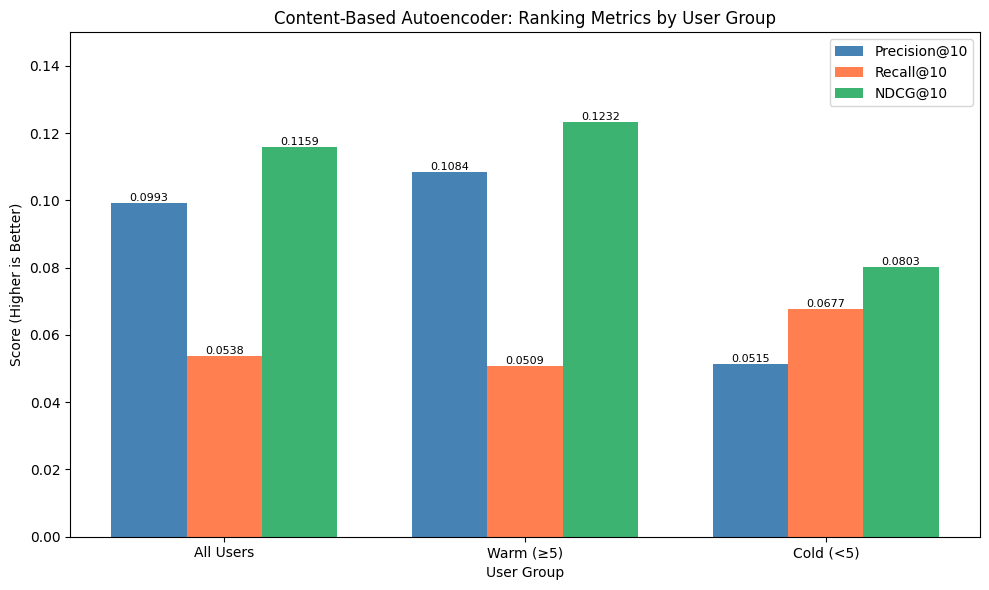

Graph saved!


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Data
groups = ['All Users', 'Warm (≥5)', 'Cold (<5)']
precision = [0.0993, 0.1084, 0.0515]
recall = [0.0538, 0.0509, 0.0677]
ndcg = [0.1159, 0.1232, 0.0803]

x = np.arange(len(groups))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, precision, width, label='Precision@10', color='steelblue')
bars2 = ax.bar(x, recall, width, label='Recall@10', color='coral')
bars3 = ax.bar(x + width, ndcg, width, label='NDCG@10', color='mediumseagreen')

# Add value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('User Group')
ax.set_ylabel('Score (Higher is Better)')
ax.set_title('Content-Based Autoencoder: Ranking Metrics by User Group')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()
ax.set_ylim(0, 0.15)

plt.tight_layout()
plt.savefig('ranking_metrics_by_group.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved!")

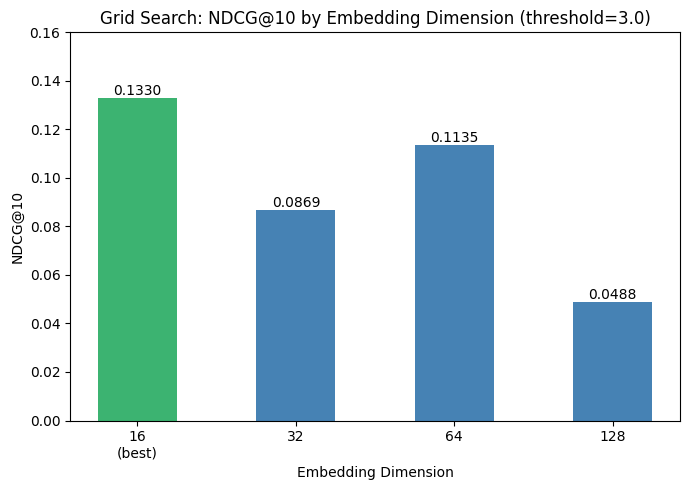

Grid search chart saved!


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Grid search results - best NDCG per embedding dim (threshold=3.0)
dims = ['16\n(best)', '32', '64', '128']
ndcg_vals = [0.1330, 0.0869, 0.1135, 0.0488]
colors = ['mediumseagreen', 'steelblue', 'steelblue', 'steelblue']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(dims, ndcg_vals, color=colors, width=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Embedding Dimension')
ax.set_ylabel('NDCG@10')
ax.set_title('Grid Search: NDCG@10 by Embedding Dimension (threshold=3.0)')
ax.set_ylim(0, 0.16)

plt.tight_layout()
plt.savefig('grid_search_ndcg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grid search chart saved!")